# <center>Clustering of titles</center>
---

This code aims to cluster the titles of YouTube videos, trying to search for videos related to politics

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
from langdetect import detect, DetectorFactory
from multiprocessing import Pool, cpu_count
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

nltk.download("stopwords")
stop_words = stopwords.words("english")

vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),   # unigrams + bigrams (captura combinações de palavras)
    max_features=5000     # limita vocabulário para economizar memória
)

Melhor valor de K encontrado pela 2ª derivada: K = 6
Primeira Derivada: [ 1.47132486e-05  4.71837608e-06  2.41849644e-05  2.48651723e-05
 -8.24252798e-06 -7.38909386e-05 -7.59629088e-05 -1.16160648e-05
 -3.77867750e-05 -3.01170411e-05  3.18075835e-05  2.56326154e-05
  6.12579802e-05  7.38492031e-05  3.15318665e-05  5.28420040e-06
 -3.06029783e-05 -3.03633878e-05]
Segunda Derivada: [-9.99487250e-06  4.73585791e-06  1.00733981e-05 -1.62137462e-05
 -4.93780555e-05 -3.38601904e-05  3.11374369e-05  1.90880669e-05
 -9.25048818e-06  3.47971793e-05  2.78748282e-05  1.47251984e-05
  2.41082939e-05 -1.48630569e-05 -3.42825014e-05 -3.10674224e-05
 -1.78237941e-05  2.39590469e-07]


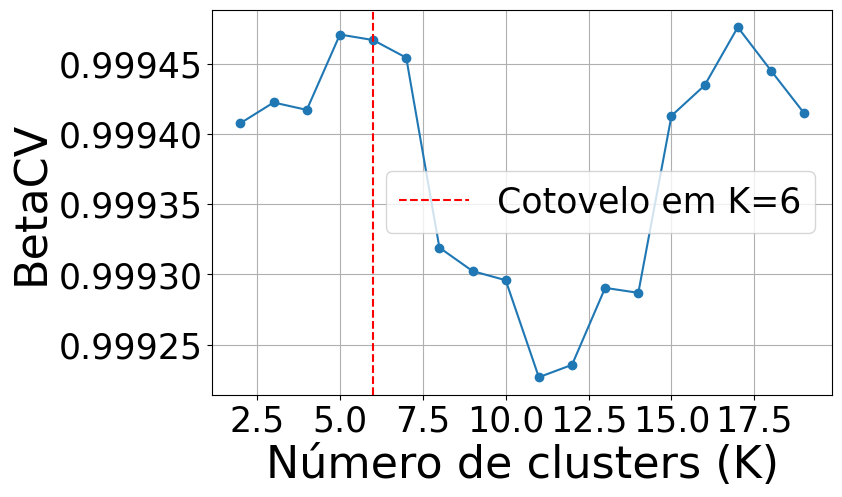

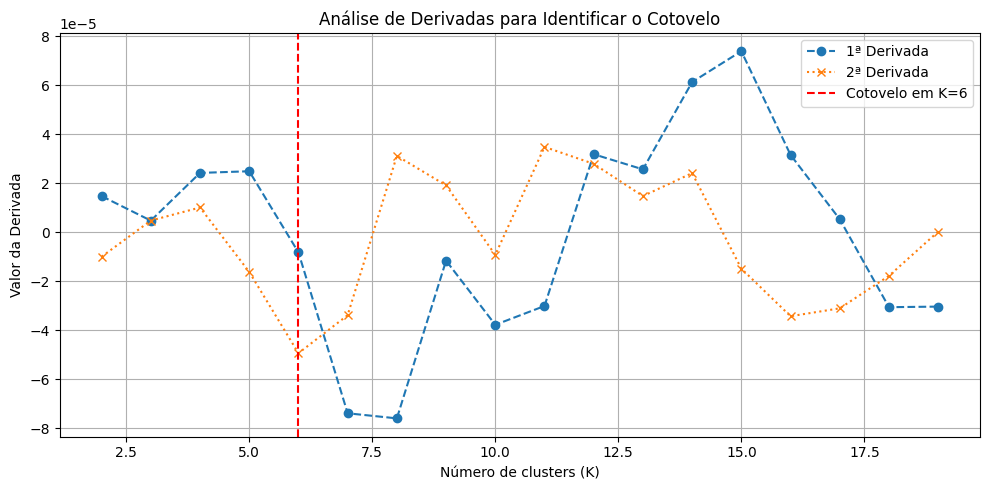

In [36]:
df_sample = df_en.sample(10000, random_state=42)
X_tfidf = vectorizer.fit_transform(df_sample["clean_title"])

# Definição da função BetaCV (avalia a qualidade de um agrupamento; quanto menor, melhor)
def beta_cv(X, labels):
    distances = pairwise_distances(X) # DIstancia entre todos os pontos
    n = len(labels) # Número de amostras 
    
    # Soma das distâncias dentro de um cluster
    def intra_cluster_distance(dist_row, labels, idx):
        same_cluster = labels == labels[idx]
        same_cluster[idx] = False
        return np.sum(dist_row[same_cluster])

    # Soma das distâncias para pontos em outro cluster
    def inter_cluster_distance(dist_row, labels, idx):
        other_cluster = labels != labels[idx]
        return np.sum(dist_row[other_cluster])

    # Calcula as somas intra e inter para cada ponto
    A = np.array([intra_cluster_distance(distances[i], labels, i) for i in range(n)])
    B = np.array([inter_cluster_distance(distances[i], labels, i) for i in range(n)])

    a = np.sum(A) # Soma total intra-cluster
    b = np.sum(B) # Soma total inter-cluster

    # Conta os membros de cada cluster
    labels_unq = np.unique(labels)
    members = np.array([(labels == lbl).sum() for lbl in labels_unq])

    # Número total de pares intra-cluster possíveis
    N_in = np.array([m * (m - 1) for m in members])
    n_in = np.sum(N_in)

    # Número total de pares inter-cluster possíveis
    N_out = np.array([m * (n - m) for m in members])
    n_out = np.sum(N_out)

    # Cálculo do índice BetaCV
    beta_cv_value = (a / n_in) / (b / n_out)

    return beta_cv_value


# 2. Rodar KMeans para vários valores de K e calcular BetaCV
k_values = range(2, 20)
betacv_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_tfidf)
    score = beta_cv(X_tfidf, labels)
    betacv_scores.append(score)

# Derivadas numéricas (usando diferenças finitas)
first_derivative = np.gradient(betacv_scores)
second_derivative = np.gradient(first_derivative)

# O ponto de cotovelo pode ser aquele com maior curvatura (mínimo da segunda derivada)
knee_index = np.argmin(second_derivative)
melhor_k = k_values[knee_index]

print(f"Melhor valor de K encontrado pela 2ª derivada: K = {melhor_k}")
print(f"Primeira Derivada: {first_derivative}")
print(f"Segunda Derivada: {second_derivative}")

# PLot do Método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(k_values, betacv_scores, marker='o')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.xlabel('Número de clusters (K)', fontsize=32)
plt.ylabel('BetaCV', fontsize=32)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)
plt.show()

# --- Plot 2: Derivadas ---
plt.figure(figsize=(10, 5))
plt.plot(k_values, first_derivative, label='1ª Derivada', marker='o', linestyle='--')
plt.plot(k_values, second_derivative, label='2ª Derivada', marker='x', linestyle=':')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Cotovelo em K={melhor_k}')
plt.title('Análise de Derivadas para Identificar o Cotovelo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Valor da Derivada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


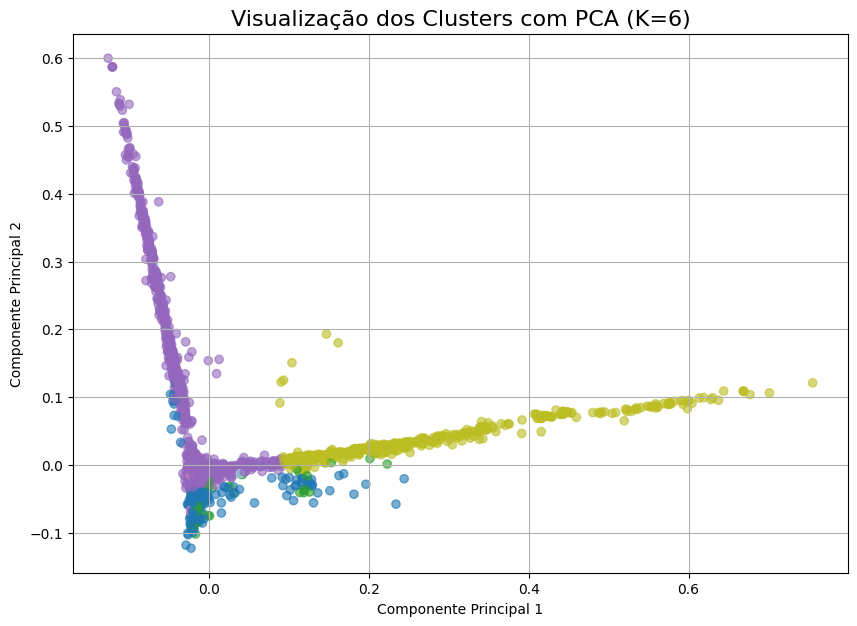

Cluster 0: 476 pontos
Cluster 1: 117 pontos
Cluster 2: 8686 pontos
Cluster 3: 72 pontos
Cluster 4: 595 pontos
Cluster 5: 54 pontos


In [37]:
from sklearn.decomposition import PCA

# 1. Defina o número de clusters
#k = 20 # ou use melhor_k, se tiver definido anteriormente


# 2. Aplique KMeans com o K escolhido
kmeans = KMeans(n_clusters=melhor_k, random_state=42)
labels = kmeans.fit_predict(X_tfidf)

# 3. Reduza para 2 dimensões usando PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

# 4. Plote os clusters em 2D
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab20", alpha=0.6)
plt.title(f"Visualização dos Clusters com PCA (K={melhor_k})", fontsize=16)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# labels contém o cluster atribuído a cada ponto
counts = np.bincount(labels)
df_sample["cluster"] = labels

# Printar o número de pontos em cada cluster
for cluster_id, count in enumerate(counts):
    print(f"Cluster {cluster_id}: {count} pontos")


In [39]:
# Adicionar os labels ao dataframe
df_sample["cluster"] = labels

# Mostrar exemplos de cada cluster
for c in range(melhor_k):
    cluster_videos = df_sample[df_sample["cluster"] == c]["clean_title"]
    n_videos = len(cluster_videos)
    exemplos = cluster_videos.head(15).tolist()  # 5 exemplos
    print(f"\nCluster {c} ({n_videos} vídeos):")
    for ex in exemplos:
        print("  -", ex)



Cluster 0 (476 vídeos):
  - trump contro tutti  mazzucco live  puntata
  - blind justice trump trial goes to the jury  the newsmax daily
  - devin nunes trump communications incidentally collected by intelligence agencies  nbc news
  - joe biden warns there will be no peaceful transfer if trump wins in stupid gaffe
  - judge accuses trump of intimidating jurors threatens him with jail time allows biased jurors
  - trump wins making sense of election night
  - dan bongino to matt gaetz this is how coverup around trump assassination attempt would work
  - it begins   us cities  states erupt against trump  officials issue statement
  - watch rare barron trump moments with donald and melania  et vault unlocked
  - what did trump mean by bloodbath
  - team trump exposes michael cohen in explosive cross examination
  - why eric adams is in trouble tyt joebiden trump short shorts
  - trump jr desperate dems hoax all they have left to rescue disaster kamala
  - newsmax ready for trump bronx r